# Transfer learning in Pytorch

## [Colab](https://github.com/MVRonkin/DLCVCourseEn/tree/main/WS/WS5transfer.ipynb)

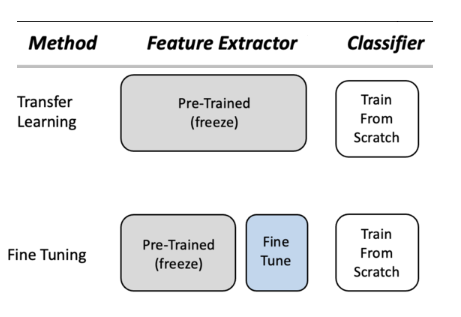

<img src="https://www.researchgate.net/profile/Md-Motiur-Rahman-Sagar/publication/344197871/figure/fig5/AS:934418801778698@1599794211953/Fixed-feature-extraction-and-fine-tuning-method-of-transfer-learning-56_W640.jpg">

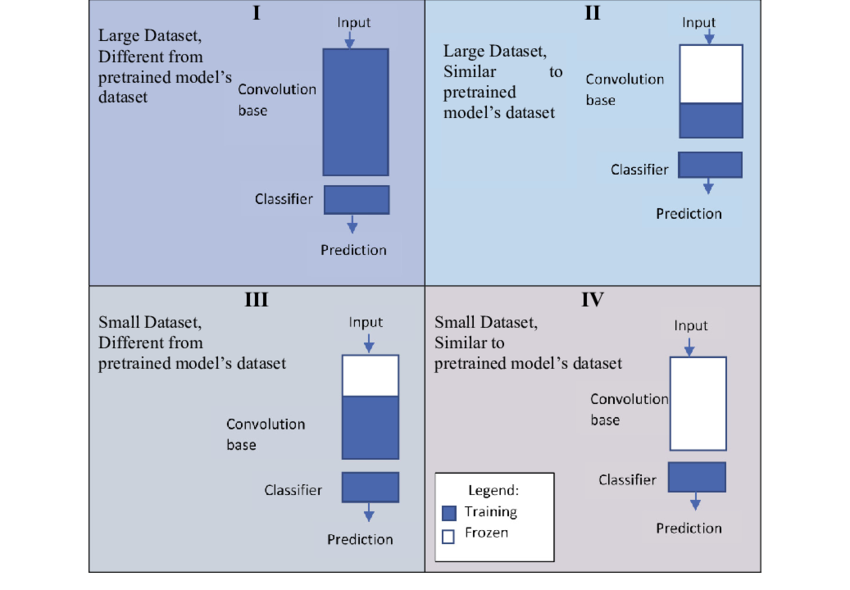

# 📚 Where to Find Pre-trained Models

> **Important:** Always ask yourself: *"Is there a pre-trained model available for my task?"* at the start of any deep learning project.

The world of deep learning is built on the principle of open collaboration: researchers and engineers worldwide share their work. Often, code and pre-trained models for state-of-the-art research are published on platforms like `GitHub` within days of the original paper's release. The papers themselves are frequently available as `preprints` (e.g., on [arXiv](https://arxiv.org/)) before formal peer review.

Therefore, there is a set of standard resources where you can find pre-trained models to jump-start your own projects.

---

## 🔍 Key Resources for Pre-trained Models

| **Location** | **What's here?** | **Link(s)** |
|--------------|-----------------|-------------|
| **PyTorch Domain Libraries** | Each PyTorch domain library (e.g., `torchvision`, `torchaudio`, `torchtext`) provides pre-trained models ready to use directly in PyTorch. | [`torchvision.models`](https://pytorch.org/vision/stable/models.html), [`torchhub`](https://pytorch.org/hub/) |
| **Hugging Face Hub** | A vast collection of pre-trained models across multiple domains—including computer vision, NLP, audio, and multimodal architectures—from organizations and researchers worldwide. Also hosts many datasets. | [Models](https://huggingface.co/models), [Datasets](https://huggingface.co/datasets) |
| **[`timm` (PyTorch Image Models)](https://huggingface.co/timm)** | Nearly all recent and top-performing computer vision models implemented in PyTorch, plus many useful utilities for vision tasks. | [GitHub Repo](https://github.com/rwightman/pytorch-image-models) |
<!-- | **Papers with Code** | A curated collection of recent ML papers with linked code implementations. Also features model benchmarks and SOTA leaderboards across tasks. | [https://paperswithcode.com](https://paperswithcode.com) | -->

> 💡 **Best Practice:** Accessing high-quality resources like those above should become a standard step in your workflow. Before building a model from scratch, always check: *"Does a suitable pre-trained model already exist for my problem?"*

---

## 🔧 Architecture-Specific Repositories

For specific model architectures, dedicated repositories often provide clean, well-maintained implementations:

- [**vit-pytorch**](https://github.com/lucidrains/vit-pytorch) — Vision Transformer (ViT) implementations
- [**mlp-mixer-pytorch**](https://github.com/lucidrains/mlp-mixer-pytorch) — MLP-Mixer architecture in PyTorch
- [**GitHub Marketplace Models**](https://github.com/marketplace/models) — Official model repository from GitHub (newly launched)

These resources can save you significant time and help ensure your implementations follow current best practices.

In [1]:
!pip3 install torchsummary

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

import os
import copy
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data

import torchvision
from torchvision import transforms, datasets
import torchvision.transforms as T

from torchsummary import summary

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from tqdm.notebook import tqdm, trange

import pandas as pd

Settings for working with `PyTorch`. 

In [3]:
def setup_experiment(seed = 42, deterministic = True, 
                     benchmark = False, allow_tf32 = True, device_preference = "auto"):
    """
    Настраивает окружение для воспроизводимых экспериментов в PyTorch.

    Args:
        seed (int): Сид для генераторов случайных чисел (Python, NumPy, PyTorch).
        deterministic (bool): Включить детерминированное поведение операций CuDNN (может снизить скорость).
        benchmark (bool): Включить CuDNN benchmark для автоматического выбора быстрых алгоритмов (не совместимо с deterministic=True).
        allow_tf32 (bool): Разрешить использование TensorFloat32 на Ampere+ GPU (ускоряет вычисления с небольшой потерей точности).
        device_preference (str): "cpu", "cuda", "mps", или "auto" — выбор устройства.
        benchmark=True ускоряет обучение, но нарушает воспроизводимость
        deterministic=True гарантирует воспроизводимость, но может замедлить

    Returns:
        torch.device: Устройство, на котором будут выполняться вычисления.
    """
    # --- 1. Установка сидов ---
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # для multi-GPU

    # --- 2. Настройки CuDNN ---
    if torch.backends.cudnn.is_available():
        torch.backends.cudnn.deterministic = deterministic
        torch.backends.cudnn.benchmark = benchmark

    # --- 3. TF32 (только для CUDA на Ampere и новее) ---
    if torch.cuda.is_available() and hasattr(torch.backends.cuda, 'matmul'):
        torch.backends.cuda.matmul.allow_tf32 = allow_tf32
        torch.backends.cudnn.allow_tf32 = allow_tf32

    # --- 4. Подавление некоторых предупреждений (опционально) ---
    if device_preference == "auto":
        device = (
            torch.device("mps") if torch.backends.mps.is_available() else
            torch.device("cuda") if torch.cuda.is_available() else
            torch.device("cpu")
        )
    elif device_preference in ("cpu", "cuda", "mps"):
        if device_preference == "cuda" and not torch.cuda.is_available():
            raise RuntimeError("CUDA not available, but 'cuda' was requested.")
        if device_preference == "mps" and not torch.backends.mps.is_available():
            raise RuntimeError("MPS not available, but 'mps' was requested.")
        device = torch.device(device_preference)
    else:
        raise ValueError("device_preference must be 'auto', 'cpu', 'cuda', or 'mps'")

    # --- 6. Печать итоговой конфигурации ---
    print(f"[Setup] Seed: {seed}")
    print(f"[Setup] Device: {device}")
    print(f"[Setup] CuDNN deterministic: {deterministic}, benchmark: {benchmark}")
    if torch.cuda.is_available():
        print(f"[Setup] TF32 enabled: {allow_tf32}")
    print("-" * 50)

    return device   


In [4]:
device = setup_experiment()
# device = torch.device('cpu')

[Setup] Seed: 42
[Setup] Device: cuda
[Setup] CuDNN deterministic: True, benchmark: False
[Setup] TF32 enabled: True
--------------------------------------------------


In the practice we are very rarely apply neural network architectures trained "from zero". It is more often to use so-called pretrained architectures. This term means architectures  weights initialization using parameters obtained for some very large dataset which is frequently does not correspond to our goal data. For instance, weights can be obtained for `ImageNet` dataset with 1.2 millions images of 1000 classes. 

We can use pretrained architecture either as initialization adjusted for correct using of features or as predefined (freeze) feature extractor. In both cases for retrained architecture  we need to change head part (at least last layer for our - with our number of classes).

Pretrained architectures can obtained form different sources. One of them is using module [`torchvision.models`]((https://pytorch.org/vision/0.8/models.html)).




Let's start with model `resnet18`. This architecture is the smallest model from ResNet family,. You may learn about the model on the`torchvision` [web page](https://pytorch.org/vision/stable/generated/torchvision.models.resnet18.html), also [here](https://pytorch.org/hub/pytorch_vision_resnet/) and [here](https://arxiv.org/pdf/1512.03385.pdf).
<img src="https://pytorch.org/assets/images/resnet.png"  wide = 150 high = 100> 
* https://arxiv.org/pdf/1512.03385.pdf

For uploading the pretrained model we need to set the corresponding argument `pretrained=True`.

>*Note*, we may also create general model form```torchvision.models.ResNet()``` with block description. <br>
Also we me upload the model from module `torch.hub`, for instance, as follows.
>```python
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
>```
> ypu may learn about  `torch.hub` [here](https://pytorch.org/hub/research-models/compact).

In [5]:
import ssl
ssl._create_default_https_context = ssl._create_stdlib_context

In [6]:
# model = torchvision.models.mobilenet_v2(weights=torchvision.models.mobilenetv2.MobileNet_V2_Weights.IMAGENET1K_V1)
model = torchvision.models.resnet18(weights='ResNet18_Weights.IMAGENET1K_V1')
summary(model,input_size=(3, 224, 224))

C:\Users\MVRonkin\miniconda3\Lib\site-packages\torch\cuda\__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GeForce RTX 5060 Ti which is of cuda capability 12.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (5.0) - (9.0)
    
  queued_call()
C:\Users\MVRonkin\miniconda3\Lib\site-packages\torch\cuda\__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.8 13.0 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
C:\Users\MVRonkin\miniconda3\Lib\site-packages\torch\cuda\__init__.py:435: UserWarning: 
NVIDIA GeForce RTX 5060 Ti with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5060 Ti GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queue

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
# model = torchvision.models.efficientnet_b0(pretrained=True)
# summary(model,input_size=(3, 32, 32))

Also for the following treatment of the model we need to know the structure of the model

In [37]:
for name,_ in model.named_children():
    print(name)

conv1
bn1
relu
maxpool
layer1
layer2
layer3
layer4
avgpool
fc


After uploading we will need to freeze all parameters of feature extractor. For this we may set argument `requires_grad == False`, after it these parameters will not participate in backward propagation.

In [38]:
#freeze all parameters
for param in model.parameters():
    param.requires_grad = False

Let's us denote that you may also obtain the information about modules as it is shown below
```python
for name, module_ in model.named_modules():
    print(name, '\t structure =',list(module_.size()))
```

let's now load the dataset, we will take it from [here](https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html).

In [12]:
import os
from torchvision.datasets.utils import download_and_extract_archive

In [13]:
url = 'https://download.pytorch.org/tutorial/hymenoptera_data.zip'
root_directory = os.path.join(os.getcwd(),'data')

archive_name = url.split('/')[-1]
dataset_directory = os.path.join(root_directory, archive_name)
dataset_directory = os.path.splitext(dataset_directory)[0]

download_and_extract_archive(url, root_directory)

100%|█████████████████████████████████████████████████████████████████████████████| 47.3M/47.3M [00:11<00:00, 4.26MB/s]


In [14]:
root_directory

'C:\\Users\\MVRonkin\\Documents\\GitHub\\Deep-Learning-in-Image-Processing-Lectures\\2026\\WS\\data'

We can learn content of the dataset, as it is shown below

In [15]:
content = os.listdir(dataset_directory)
print(content)
for dir_ in content:
    path_ = os.path.join(dataset_directory,dir_)
    if os.path.isdir(path_):
        print(dir_, ':\t', os.listdir(path_ ) )

['train', 'val']
train :	 ['ants', 'bees']
val :	 ['ants', 'bees']


Now our dataset folders consists of two classes for train and validation parts. Let's create these datasets. For this operation we will use `ImageFolder` class from `torchvision.datasets` module.

In [16]:
train_transform =  transforms.Compose([
        transforms.Resize(256),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], 
                             [0.229, 0.224, 0.225])
    ])

test_transform = transforms.Compose([
        transforms.Resize(224),  
        transforms.CenterCrop(224), # TODO:check input size .
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], 
                             [0.229, 0.224, 0.225])
    ])

traindata = datasets.ImageFolder(os.path.join(dataset_directory, 'train'),train_transform)

valdata   = datasets.ImageFolder(os.path.join(dataset_directory, 'val'),test_transform)

names_classes = traindata.classes
print(names_classes)

print(f'Number of training examples: {len(traindata)}')
print(f'Number of validation examples: {len(valdata)}')

['ants', 'bees']
Number of training examples: 244
Number of validation examples: 153


Now we can create dataloader.

*Note*, If you use `GPU`, we will specify cuda random generator.

In [1]:
BATCH_SIZE = 4
if torch.cuda.is_available():
    kwarg = {'generator':torch.Generator(device='cpu')}
else:
    kwarg = {'num_workers':min(BATCH_SIZE, num_workers)}

trainloader = torch.utils.data.DataLoader(traindata, batch_size=BATCH_SIZE, shuffle=True,)

valloader   = torch.utils.data.DataLoader(valdata, batch_size=BATCH_SIZE, shuffle=False)

NameError: name 'torch' is not defined

In [22]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.figure(figsize=(12,4))
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()


# Get a batch of training data
inputs, classes = next(iter(valloader))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[names_classes[x] for x in classes])

AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [24]:
inputs.shape

torch.Size([4, 3, 224, 224])

So, after dataset is ready we can create our model based on the pretrained one. Let's us remind that we upload our model with freeze parameters. Now we will replace the last layer ( `fc` - for classification) with our custom one. The input size for this layer we can obtain as attribute  `in_features` for corresponding layer. We can initialize this layer for make training more robust and fast. 

In [40]:
n_classes = len(names_classes)

# Parameters of newly constructed modules have requires_grad=True by default
n_fc_in = model.fc.in_features

model.fc = nn.Linear(n_fc_in, n_classes)

nn.init.xavier_uniform_(model.fc.weight)
model.fc.bias.data.fill_(0);

In [26]:
# For EFFICIENTNET B0!
# n_classes = len(names_classes)

# # Parameters of newly constructed modules have requires_grad=True by default
# n_fc_in = model.classifier[-1].in_features

# model.classifier[-1] = nn.Linear(n_fc_in, n_classes)

# nn.init.xavier_uniform_(model.classifier[-1].weight)
# model.classifier[-1].bias.data.fill_(0);

Now let's check that we have only part of parameters unfreeze - i.e. trainable.

In [41]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Number of trainable parameters for the model: %d' % (num_params))

num_params = sum(p.numel() for p in model.parameters() )
print('Number of all parameters for the model: %d' % (num_params))

Number of trainable parameters for the model: 1026
Number of all parameters for the model: 11177538


In [42]:
summary(model,(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

Also we need to extract trainable parameters for its optimization.

In [43]:
trainable_parameters = filter(lambda p: p.requires_grad, model.parameters())

So now we can initialize the model. 

Let us Note, that in this specific  case we can write `model.fc.parameters` instead of `trainable_parameters`. However our way could be more generalizable.  

In [44]:
LR = 0.001

model = model.to(device)
trainable_parameters = filter(lambda p: p.requires_grad, model.parameters())
criterion = nn.CrossEntropyLoss()
criterion = criterion.to(device)

optimizer = optim.SGD(trainable_parameters, lr=LR, momentum=0.9)


Also let's describe train, evaluation and other function

In [51]:
def accuracy(y_pred, y):
    cls_pred = y_pred.argmax(1, keepdim=True)    
    correct_cls = cls_pred.eq(y.view_as(cls_pred)).sum()
    acc = correct_cls.float() / y.shape[0]
    return acc

#-------------------    
def train(model, dataloader, optimizer, criterion, metric,  device):

    epoch_loss = 0
    epoch_acc  = 0

    model.train()

    for (x, y) in tqdm(dataloader, desc="Training", leave=False):

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none = True)

        y_pred = model(x)

        loss = criterion(y_pred, y)
        acc  = metric(y_pred, y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc  += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)
#-------------------
def evaluate(model, dataloader, criterion, metric, device):

    epoch_loss = 0
    epoch_acc  = 0

    model.eval()

    with torch.inference_mode():
        
        for (x, y) in tqdm(dataloader, desc="Evaluating", leave=False):

            x, y = x.to(device), y.to(device)

            y_pred = model.forward(x)

            loss = criterion(y_pred, y)
            acc  = metric( y_pred, y)

            epoch_loss += loss.item()
            epoch_acc  += acc.item()

    return epoch_loss / len(dataloader), epoch_acc / len(dataloader)

#-------------------
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

#-------------------
def fit(model, train_loader, val_loader, optimizer, criterion, metric, epochs = 10, device='cpu', scheduler = None,  path_best = 'best_model.pt', verbose = True):
    
    best_valid_loss = float('inf')

    for epoch in trange(epochs):

        start_time = time.monotonic()

        train_loss, train_acc = train(model, train_loader, optimizer, criterion, metric, device)
        valid_loss, valid_acc = evaluate(model, val_loader, criterion, metric, device)
        
        if scheduler != None:
            scheduler.step()
        
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model.state_dict(), path_best)
        
        end_time = time.monotonic()

        epoch_mins, epoch_secs = epoch_time(start_time, end_time)       
    
        if verbose == True:
            if epoch%2 == 1:    # print every 2 epochs:
                print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s | LR {optimizer.param_groups[0]["lr"] :.4f}')
                print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%',
                f' | Val. Loss: {valid_loss:.3f} | Val. Acc: {valid_acc*100:.2f}%') 

Let's check the accuracy before training

In [46]:
best_epoch = 0
test_loss, test_acc = evaluate(model, valloader, criterion,accuracy, device)
print(f'best epoch {best_epoch}: Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

best epoch 0: Test Loss: 0.773 | Test Acc: 62.18%


Now we can train our network

In [53]:
fit(model, trainloader, valloader, optimizer, criterion, accuracy, epochs = 2, device=device, verbose = True)

  0%|          | 0/2 [00:00<?, ?it/s]

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch: 02 | Epoch Time: 0m 1s | LR 0.0010
	Train Loss: 0.438 | Train Acc: 81.56%  | Val. Loss: 0.345 | Val. Acc: 89.10%


In [54]:
model.load_state_dict(torch.load('best_model.pt'))
test_loss, test_acc = evaluate(model, valloader, criterion, accuracy, device)
print(10*'--',f'\n Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

-------------------- 
 Test Loss: 0.257 | Test Acc: 93.59%


The above training was fast enough and show well results. However, for educational purposes we can go deeper. 

Let's change  `layer4` form the original model to custom one.



In [56]:
for p in model.layer4.named_modules():
    print(p[0])


0
0.conv1
0.bn1
0.relu
0.conv2
0.bn2
0.downsample
0.downsample.0
0.downsample.1
1
1.conv1
1.bn1
1.relu
1.conv2
1.bn2


Let's also note that each layer from module can be taken using `get_submodule()`. If you need some specific parameters you may also use `get_parameters()`.

Also while we using as linear, a relu activation (for con layer) we ought to rewrite initialization function.
.

In [57]:
def init_weights(m):
    
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight)
    
    elif isinstance(m, nn.Linear): 
        nn.init.xavier_uniform_(m.weight)
    
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        if m.bias != None:
            m.bias.data.fill_(0)

Now we can make trainable our layers under investigation( `model.layer4`), also we make initialization for trainable parameters. 

In [58]:
for  m in [model.layer4, model.fc]:
    for param in m.named_parameters():
        print(param[0])
        param[1].requires_grad = True
    m.apply(init_weights);  

0.conv1.weight
0.bn1.weight
0.bn1.bias
0.conv2.weight
0.bn2.weight
0.bn2.bias
0.downsample.0.weight
0.downsample.1.weight
0.downsample.1.bias
1.conv1.weight
1.bn1.weight
1.bn1.bias
1.conv2.weight
1.bn2.weight
1.bn2.bias
weight
bias


Let's now check the number of trainable parameters

In [59]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Number of trainable parameters for the model: %d' % (num_params))

Number of trainable parameters for the model: 8394754


Let us note, that if you want to re initialize only part of  `layer4`, you may do it as follows:
```python
layer_ = model.layer4.get_submodule('1.conv2')
for  m in [layer_, model.fc]:
    for param in m.parameters():
        param.requires_grad = True
    m.apply(init_weights);   
```

So the accuracy before training 

In [60]:
best_epoch = 0
test_loss, test_acc = evaluate(model, valloader, criterion, accuracy, device)
print(f'best epoch {best_epoch}: Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

best epoch 0: Test Loss: 34.939 | Test Acc: 55.13%


model initialize

In [61]:
LR = 0.001

model = model.to(device)

criterion = nn.CrossEntropyLoss()

criterion = criterion.to(device)


In [62]:
trainable_parameters = []
for p in model.parameters():
    if p.requires_grad:
        trainable_parameters +=[p]

optimizer = optim.SGD(trainable_parameters, lr=LR, momentum=0.9)    

Training

In [63]:
fit(model, trainloader, valloader, optimizer, criterion, accuracy, epochs = 2, device=device, verbose = True)

  0%|          | 0/2 [00:00<?, ?it/s]

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch: 02 | Epoch Time: 0m 1s | LR 0.0010
	Train Loss: 0.746 | Train Acc: 67.62%  | Val. Loss: 0.421 | Val. Acc: 86.54%


Obtained results are lower the the previous one. This is connected with large part of the network we are training. 


Also in some cases you may want to exceed the model. 

You may exceed the model with creating freeze feature extractor by deleting undesired layers.

In [64]:
new_model_ = nn.Sequential(*list(model.children())[:-2])
summary(new_model_,input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [66]:
x = torch.randn((4,3,224,224), device=device)

out = new_model_(x)
print(out.shape)

n_features = out.shape[1]

torch.Size([4, 512, 7, 7])


Now we can crate new model. Our model can be described as class. We will create model with one conv layer, global average pooling and new head, containing one hidden layer with `n_features` as input and  `n_classes` as output.

In [69]:
class NewResNet(nn.Module):
    def __init__(self, resnet18, n_features=512, n_classes=2):
        super().__init__()
        
        self.new_model_ = nn.Sequential(*list(resnet18.children())[:-2])
        
        for param in self.new_model_.parameters():
            param.requires_grad = False
            
        self.conv_last  = nn.Conv2d(in_channels  = n_features, 
                                    out_channels = 1024, 
                                    kernel_size  = 3,
                                    stride       = 1,
                                    padding      = 1,
                                    dilation     = 1)
        
        self.conv_last.apply(self.init_weights)
        
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        
        self.fc  = nn.Linear(in_features = 1024, 
                                out_features = n_classes) 
        
        for m in [self.conv_last, self.fc]:
            m.apply(self.init_weights)
    
    #---------------------------------------------
    def init_weights(self, m):
    
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight)

        elif isinstance(m, nn.Linear): 
            nn.init.xavier_uniform_(m.weight)

        if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
            if m.bias != None:
                m.bias.data.fill_(0)
    
    #---------------------------------------------        
    def forward(self,x):
        x = self.new_model_(x)

        x = torch.relu(self.conv_last(x))
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x
        

let's check the structure of our model

In [70]:
model = torchvision.models.resnet18(pretrained=True)

new_model = NewResNet(model)
summary(new_model,input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [75]:
LR = 0.001

new_model = new_model.to(device)

criterion = nn.CrossEntropyLoss()

criterion = criterion.to(device)


In [76]:
trainable_parameters = []
for p in new_model.parameters():
    if p.requires_grad:
        trainable_parameters +=[p]

optimizer = optim.SGD(trainable_parameters, lr=LR, momentum=0.9)    

check accuracy before training

In [77]:
best_epoch = 0
test_loss, test_acc = evaluate(new_model, valloader, criterion, accuracy, device)
print(10*'--',f'\nbest epoch {best_epoch}: Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

-------------------- 
best epoch 0: Test Loss: 0.988 | Test Acc: 35.26%


In [78]:
fit(new_model, trainloader, valloader, optimizer, criterion, accuracy, epochs = 10, device=device, verbose = True)

  0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

...

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch: 10 | Epoch Time: 0m 2s | LR 0.0010
	Train Loss: 0.382 | Train Acc: 83.20%  | Val. Loss: 0.249 | Val. Acc: 89.10%


In [81]:
new_model.load_state_dict(torch.load('best_model.pt'))
test_loss, test_acc = evaluate(new_model, valloader, criterion, accuracy, device)
print(10*'--',f'\n Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

-------------------- 
 Test Loss: 0.204 | Test Acc: 92.95%


So now we are improve the accuracy of our model

* torch - torchvision.models, torchhub,
* huggingface - https://huggingface.co/models,
* timm - https://github.com/rwightman/pytorch-image-models
* benchmark models - https://paperswithcode.com/
* specific repositories like yolo https://docs.ultralytics.com/

In [126]:
import timm
model_names = timm.list_models('resnet*')
print(model_names[:15])

['resnet10t', 'resnet14t', 'resnet18', 'resnet18d', 'resnet26', 'resnet26d', 'resnet26t', 'resnet32ts', 'resnet33ts', 'resnet34', 'resnet34d', 'resnet50', 'resnet50_clip', 'resnet50_clip_gap', 'resnet50_gn']


In [127]:
model = timm.create_model('resnet18', pretrained=True, num_classes=2, in_chans=3)
out = model(torch.randn(7, 3, 224, 224))
print(f'Unpooled shape: {out.shape}')

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Unpooled shape: torch.Size([7, 2])


C:\Users\Ronkin\myenv\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Ronkin\.cache\huggingface\hub\models--timm--resnet18.a1_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [128]:
for name,_ in model.named_children():
    print(name, end=', ')

conv1, bn1, act1, maxpool, layer1, layer2, layer3, layer4, global_pool, fc, 

In [129]:
model.get_classifier()

Linear(in_features=512, out_features=2, bias=True)

In [130]:
for param in model.parameters():
    param.requires_grad = False

In [131]:
n_in_fc = model.fc.in_features
model.fc = nn.Linear(n_in_fc, 2)

In [137]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print('trainable p:', trainable_params, 'all p:', total_params)    

trainable p: 1026 all p: 11177538


In [138]:
summary(model, input_size =(3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
          Identity-7           [-1, 64, 56, 56]               0
              ReLU-8           [-1, 64, 56, 56]               0
          Identity-9           [-1, 64, 56, 56]               0
           Conv2d-10           [-1, 64, 56, 56]          36,864
      BatchNorm2d-11           [-1, 64, 56, 56]             128
             ReLU-12           [-1, 64, 56, 56]               0
       BasicBlock-13           [-1, 64, 56, 56]               0
           Conv2d-14           [-1, 64,

In [141]:
optimizer = optim.Adam(trainable_parameters, lr=1e-3)   
criterion = nn.CrossEntropyLoss()
criterion.to(device)

CrossEntropyLoss()

In [142]:
fit(model, trainloader, valloader, optimizer, criterion, accuracy, epochs = 10, device=device, verbose = True)

  0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

...

Training:   0%|          | 0/61 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

Epoch: 08 | Epoch Time: 0m 2s | LR 0.0010
	Train Loss: 0.687 | Train Acc: 52.87%  | Val. Loss: 0.686 | Val. Acc: 55.77%


Training:   0%|          | 0/61 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [97]:
model.load_state_dict(torch.load('best_model.pt'))
test_loss, test_acc = evaluate(model, valloader, criterion, accuracy, device)
print(10*'--',f'\n Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Evaluating:   0%|          | 0/39 [00:00<?, ?it/s]

-------------------- 
 Test Loss: 0.691 | Test Acc: 54.49%


Exercises.
1. Try to improve the `NewResNet` model.
2. Try to train `resnet18` considered in the lesson) for dataset `CIFAR-10` with `resnet18` weigth obtained on the image net as initialization. 
3. For dataset for the current workshop try __2__ of the following models (with replacement just last layer):
    * `googlenet`,
    * `mobilenet_v2`, 
    * `mobilenet_v3_small`, 
    * `efficientnet_b0`, 
    * `efficientnet_b1`, 
    * `mnasnet0_5`, 
    * `squeezenet1_1`, 
    * `shufflenet_v2_x0_5`.
4. Compare the obtained results by training time , accuracy, inference time and size in storage.
<!-- 5. For one of the model from task 3 try to create new model with resting only prepared feature extractor. -->
6. Try to train full `resnet18` with using pretrained weights as only initialization (without freezing layers, but with replacement last layer for your problem) - take model from the first experiment without freezing layers - with make all you layers trainable.